## Imports

In [30]:
import warnings
warnings.filterwarnings("ignore")

In [31]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

from IPython.display import display

In [32]:
from funcoes_escoragem import *
from funcoes_monitoramento import *

## Diretório

In [33]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Performance

In [34]:
project_id = 'loft-dl-fintech'

In [35]:
project_id = 'loft-dl-datascience'

query = '''
WITH
first_defaults AS (
  SELECT
    contract_id,
    DATE(MIN(pendency_created_at)) AS first_comunicacao_date,
    DATE(MIN(pendency_at)) AS first_competencia_date,
    DATE(MIN(payment_at)) AS first_payment_date,
    DATE(MIN(reimbursement_at)) AS first_reimbursement_date
  FROM `loft-dl-fintech.cp_gold.watchlist_fact`
  WHERE pendency_type IN ('Inadimplência')
  GROUP BY contract_id
),

tb_leads as(
  SELECT
    rf.contract_id,
    date(cf.requested_at) as requested_at,
    cf.tipo,
    cf.tipo_contrato,
    cf.rule,
    cf.bureau_nm,
    cf.modeloBlend,
    rf.approved_products,
    case when '32' in unnest(json_value_array(rf.approved_products)) then 1 else 0 end as flag_pop32,
    rd.product_nm,
    case when cf.modeloBlend in ('BLEND_REGRESSAO_2026', 'BLEND_REGRESSAO') then 'BLEND2'
         when cf.modeloBlend in ('BLEND3_2', 'BLEND3_3', 'BLEND3_4') then 'BLEND3'
         when cf.modeloBlend in ('BLEND_4', 'BVS_CUSTOM_V2', 'HFT1') then 'BLEND4'
         when cf.modeloBlend in ('BLEND_4', 'BVS_CUSTOM_V2', 'HFT1') then 'BLEND4'
         when coalesce(cf.modeloBlend, '') = '' and cf.bureau_nm in ('BLEND_REGRESSAO', 'BLEND_REGRESSAO_OTIMISTA', 'BVS_CUSTOM', 'BVS_CUSTOM_OTIMISTA') then 'BLEND2'
         else 'OUTROS' end as bureau_nm_ajust,
    i.id_imobiliaria,
    i.id_cidade_ibge,
    i.cidade as imovel_cidade,
    i.uf as imovel_uf,
    ad.segmentacao as agency_segmentacao,
    rd.lead_elegivel,
    rd.proposta_iniciada,
    rd.proposta_enviada,
    rd.proposta_aprovada,
    rd.proposta_ativada,
    rd.is_activeted,
    rf.activated_at,
    rd.aprovado_motor_mesa,
    coalesce(cf.rating_score_ds, '-1') as rating_score_ds,
    case when coalesce(cf.qtd_proponentes, -1) <= 1 then 1 else 0 end as is_single_proponent,
    ca.blend_regressao_predict_nr,

    COALESCE(rd.is_activeted, cf.is_activeted) AS is_activeted,

    DATE_DIFF(
      DATE(CURRENT_DATE()),
      COALESCE(DATE(rf.activated_at), DATE(cf.requested_at)),
      DAY
    ) AS time2requested,

    CASE
      WHEN fd.first_competencia_date IS NULL OR rf.activated_at IS NULL THEN NULL
      ELSE DATE_DIFF(
        DATE_TRUNC(DATE(fd.first_competencia_date), MONTH),
        DATE_TRUNC(DATE(rf.activated_at), MONTH),
        MONTH
      )
    END AS time2def_pc,

    CASE
      WHEN fd.first_comunicacao_date IS NULL OR rf.activated_at IS NULL THEN NULL
      ELSE DATE_DIFF(
        DATE_TRUNC(DATE(fd.first_comunicacao_date), MONTH),
        DATE_TRUNC(DATE(rf.activated_at), MONTH),
        MONTH
      )
    END AS time2def_pcc,

    CASE
      WHEN fd.first_payment_date IS NULL OR rf.activated_at IS NULL THEN NULL
      ELSE DATE_DIFF(
        DATE_TRUNC(DATE(fd.first_payment_date), MONTH),
        DATE_TRUNC(DATE(rf.activated_at), MONTH),
        MONTH
      )
    END AS time2def_pd,

    CASE
      WHEN fd.first_reimbursement_date IS NULL OR rf.activated_at IS NULL THEN NULL
      ELSE DATE_DIFF(
        DATE_TRUNC(DATE(fd.first_reimbursement_date), MONTH),
        DATE_TRUNC(DATE(rf.activated_at), MONTH),
        MONTH
      )
    END AS time2def_reimbursement,

    fd.first_comunicacao_date,
    fd.first_competencia_date,
    fd.first_payment_date,
    fd.first_reimbursement_date

  from loft-dl-fintech.cp_gold.requests_fact as rf
  left join loft-dl-fintech.cp_gold.requests_dim AS rd
    on rf.contract_id = rd.contract_id
  left join loft-dl-fintech.cp_gold.credit_fact as cf
    on rf.contract_id = cf.contract_id
  left join loft-dl-fintech.cp_silver.int_credit_analyses as ca
    on rf.contract_id = ca.contract_id
  left join loft-dl-fintech.bronze_credpago_enriched.imovel as i
    on rf.contract_id = i.id
  left join loft-dl-fintech.cp_gold.agency_dim as ad
    on rd.agency_id = ad.agency_id
  left join first_defaults as fd
    on rf.contract_id = fd.contract_id
  where cf.tipo_contrato = 'PF' and
    date(cf.requested_at) >= date('2023-01-01') and
    date(cf.requested_at) < date(current_date())
),

leads_e_defaults_mob AS (
  SELECT
    *,
-- PC
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_competencia_date IS NOT NULL AND time2requested >= 120 AND time2def_pc <= 2 THEN 1
      WHEN time2requested >= 120 THEN 0
      ELSE NULL
    END AS pc_2m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_competencia_date IS NOT NULL AND time2requested >= 150 AND time2def_pc <= 3 THEN 1
      WHEN time2requested >= 150 THEN 0
      ELSE NULL
    END AS pc_3m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_competencia_date IS NOT NULL AND time2requested >= 180 AND time2def_pc <= 4 THEN 1
      WHEN time2requested >= 180 THEN 0
      ELSE NULL
    END AS pc_4m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_competencia_date IS NOT NULL AND time2requested >= 240 AND time2def_pc <= 6 THEN 1
      WHEN time2requested >= 240 THEN 0
      ELSE NULL
    END AS pc_6m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_competencia_date IS NOT NULL AND time2requested >= 330 AND time2def_pc <= 9 THEN 1
      WHEN time2requested >= 330 THEN 0
      ELSE NULL
    END AS pc_9m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_competencia_date IS NOT NULL AND time2requested >= 420 AND time2def_pc <= 12 THEN 1
      WHEN time2requested >= 420 THEN 0
      ELSE NULL
    END AS pc_12m,

-- PCC
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_comunicacao_date IS NOT NULL AND time2requested >= 60 AND time2def_pcc <= 2 THEN 1
      WHEN time2requested >= 60 THEN 0
      ELSE NULL
    END AS pcc_2m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_comunicacao_date IS NOT NULL AND time2requested >= 90 AND time2def_pcc <= 3 THEN 1
      WHEN time2requested >= 90 THEN 0
      ELSE NULL
    END AS pcc_3m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_comunicacao_date IS NOT NULL AND time2requested >= 120 AND time2def_pcc <= 4 THEN 1
      WHEN time2requested >= 120 THEN 0
      ELSE NULL
    END AS pcc_4m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_comunicacao_date IS NOT NULL AND time2requested >= 180 AND time2def_pcc <= 6 THEN 1
      WHEN time2requested >= 180 THEN 0
      ELSE NULL
    END AS pcc_6m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_comunicacao_date IS NOT NULL AND time2requested >= 270 AND time2def_pcc <= 9 THEN 1
      WHEN time2requested >= 270 THEN 0
      ELSE NULL
    END AS pcc_9m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_comunicacao_date IS NOT NULL AND time2requested >= 360 AND time2def_pcc <= 12 THEN 1
      WHEN time2requested >= 360 THEN 0
      ELSE NULL
    END AS pcc_12m,

-- PD
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_payment_date IS NOT NULL AND time2requested >= 60 AND time2def_pd <= 2 THEN 1
      WHEN time2requested >= 60 THEN 0
      ELSE NULL
    END AS pd_2m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_payment_date IS NOT NULL AND time2requested >= 90 AND time2def_pd <= 3 THEN 1
      WHEN time2requested >= 90 THEN 0
      ELSE NULL
    END AS pd_3m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_payment_date IS NOT NULL AND time2requested >= 120 AND time2def_pd <= 4 THEN 1
      WHEN time2requested >= 120 THEN 0
      ELSE NULL
    END AS pd_4m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_payment_date IS NOT NULL AND time2requested >= 150 AND time2def_pd <= 5 THEN 1
      WHEN time2requested >= 150 THEN 0
      ELSE NULL
    END AS pd_5m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_payment_date IS NOT NULL AND time2requested >= 180 AND time2def_pd <= 6 THEN 1
      WHEN time2requested >= 180 THEN 0
      ELSE NULL
    END AS pd_6m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_payment_date IS NOT NULL AND time2requested >= 270 AND time2def_pd <= 9 THEN 1
      WHEN time2requested >= 270 THEN 0
      ELSE NULL
    END AS pd_9m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_payment_date IS NOT NULL AND time2requested >= 360 AND time2def_pd <= 12 THEN 1
      WHEN time2requested >= 360 THEN 0
      ELSE NULL
    END AS pd_12m,

-- Reimbursement
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_reimbursement_date IS NOT NULL AND time2requested >= 60 AND time2def_reimbursement <= 2 THEN 1
      WHEN time2requested >= 60 THEN 0
      ELSE NULL
    END AS reimbursement_2m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_reimbursement_date IS NOT NULL AND time2requested >= 90 AND time2def_reimbursement <= 3 THEN 1
      WHEN time2requested >= 90 THEN 0
      ELSE NULL
    END AS reimbursement_3m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_reimbursement_date IS NOT NULL AND time2requested >= 120 AND time2def_reimbursement <= 4 THEN 1
      WHEN time2requested >= 120 THEN 0
      ELSE NULL
    END AS reimbursement_4m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_reimbursement_date IS NOT NULL AND time2requested >= 150 AND time2def_reimbursement <= 5 THEN 1
      WHEN time2requested >= 150 THEN 0
      ELSE NULL
    END AS reimbursement_5m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_reimbursement_date IS NOT NULL AND time2requested >= 180 AND time2def_reimbursement <= 6 THEN 1
      WHEN time2requested >= 180 THEN 0
      ELSE NULL
    END AS reimbursement_6m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_reimbursement_date IS NOT NULL AND time2requested >= 270 AND time2def_reimbursement <= 9 THEN 1
      WHEN time2requested >= 270 THEN 0
      ELSE NULL
    END AS reimbursement_9m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_reimbursement_date IS NOT NULL AND time2requested >= 360 AND time2def_reimbursement <= 12 THEN 1
      WHEN time2requested >= 360 THEN 0
      ELSE NULL
    END AS reimbursement_12m

    FROM tb_leads
)

SELECT
  bureau_nm_ajust,
  is_single_proponent,
  DATE_TRUNC(DATE(activated_at), MONTH) AS safra,
  COUNT(*) AS n_activated,
  AVG(pc_3m) AS pc_3m,
  COUNT(pc_3m) AS n_pc_3m,
  AVG(pcc_3m) AS pcc_3m,
  COUNT(pcc_3m) AS n_pcc_3m,
  AVG(pd_3m) AS pd_3m,
  COUNT(pd_3m) AS n_pd_3m,
  AVG(reimbursement_3m) AS reimbursement_3m,
  COUNT(reimbursement_3m) AS n_reimbursement_3m,
  AVG(pc_6m) AS pc_6m,
  COUNT(pc_6m) AS n_pc_6m,
  AVG(pcc_6m) AS pcc_6m,
  COUNT(pcc_6m) AS n_pcc_6m,
  AVG(pd_6m) AS pd_6m,
  COUNT(pd_6m) AS n_pd_6m,
  AVG(reimbursement_6m) AS reimbursement_6m,
  COUNT(reimbursement_6m) AS n_reimbursement_6m,
  AVG(pc_9m) AS pc_9m,
  COUNT(pc_9m) AS n_pc_9m,
  AVG(pcc_9m) AS pcc_9m,
  COUNT(pcc_9m) AS n_pcc_9m,
  AVG(pd_9m) AS pd_9m,
  COUNT(pd_9m) AS n_pd_9m,
  AVG(reimbursement_9m) AS reimbursement_9m,
  COUNT(reimbursement_9m) AS n_reimbursement_9m,
  AVG(pc_12m) AS pc_12m,
  COUNT(pc_12m) AS n_pc_12m,
  AVG(pcc_12m) AS pcc_12m,
  COUNT(pcc_12m) AS n_pcc_12m,
  AVG(pd_12m) AS pd_12m,
  COUNT(pd_12m) AS n_pd_12m,
  AVG(reimbursement_12m) AS reimbursement_12m,
  COUNT(reimbursement_12m) AS n_reimbursement_12m
FROM leads_e_defaults_mob
WHERE activated_at IS NOT NULL
  AND DATE_TRUNC(DATE(activated_at), MONTH) >= DATE('2023-01-01')
GROUP BY 1, 2, 3
ORDER BY 1, 2, 3
'''

In [36]:
df_sim_ctr = pd.read_gbq(query, project_id=project_id)
df_sim_ctr

,bureau_nm_ajust,is_single_proponent,safra,n_activated,pc_3m,n_pc_3m,pcc_3m,n_pcc_3m,pd_3m,n_pd_3m,...,reimbursement_9m,n_reimbursement_9m,pc_12m,n_pc_12m,pcc_12m,n_pcc_12m,pd_12m,n_pd_12m,reimbursement_12m,n_reimbursement_12m
0,BLEND2,0,2023-05-01,1,0.000000,1,0.000000,1,0.000000,1,...,0.000000,1,1.0,1,1.0,1,0.0,1,0.0,1
1,BLEND2,0,2023-09-01,1,0.000000,1,0.000000,1,0.000000,1,...,0.000000,1,0.0,1,0.0,1,0.0,1,0.0,1
2,BLEND2,0,2023-11-01,1,0.000000,1,0.000000,1,0.000000,1,...,0.000000,1,1.0,1,1.0,1,0.0,1,0.0,1
3,BLEND2,0,2023-12-01,1,0.000000,1,0.000000,1,0.000000,1,...,0.000000,1,0.0,1,0.0,1,0.0,1,0.0,1
4,BLEND2,0,2024-09-01,1,0.000000,1,0.000000,1,0.000000,1,...,0.000000,1,0.0,1,0.0,1,0.0,1,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,OUTROS,1,2025-10-01,448,0.058036,448,0.040179,448,0.008929,448,...,0.091518,448,NaN,0,NaN,0,NaN,0,NaN,0
160,OUTROS,1,2025-11-01,243,0.082305,243,0.061728,243,0.020576,243,...,0.156379,243,NaN,0,NaN,0,NaN,0,NaN,0
161,OUTROS,1,2025-12-01,792,0.122475,792,0.101010,792,0.027778,792,...,0.151592,785,NaN,0,NaN,0,NaN,0,NaN,0
162,OUTROS,1,2026-01-01,6,0.000000,6,0.000000,6,0.000000,6,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0


In [37]:
df_sim_ctr.to_parquet(ANALYTICS_DIR / "df_performance_modelos_concessao.parquet")

## Base Completa

In [38]:
df_base = pd.read_parquet(f"{ANALYTICS_DIR}/df_performance_modelos_concessao.parquet")
df_base["safra"] = pd.to_datetime(df_base["safra"])
df_base

,bureau_nm_ajust,is_single_proponent,safra,n_activated,pc_3m,n_pc_3m,pcc_3m,n_pcc_3m,pd_3m,n_pd_3m,...,reimbursement_9m,n_reimbursement_9m,pc_12m,n_pc_12m,pcc_12m,n_pcc_12m,pd_12m,n_pd_12m,reimbursement_12m,n_reimbursement_12m
0,BLEND2,0,2023-05-01,1,0.000000,1,0.000000,1,0.000000,1,...,0.000000,1,1.0,1,1.0,1,0.0,1,0.0,1
1,BLEND2,0,2023-09-01,1,0.000000,1,0.000000,1,0.000000,1,...,0.000000,1,0.0,1,0.0,1,0.0,1,0.0,1
2,BLEND2,0,2023-11-01,1,0.000000,1,0.000000,1,0.000000,1,...,0.000000,1,1.0,1,1.0,1,0.0,1,0.0,1
3,BLEND2,0,2023-12-01,1,0.000000,1,0.000000,1,0.000000,1,...,0.000000,1,0.0,1,0.0,1,0.0,1,0.0,1
4,BLEND2,0,2024-09-01,1,0.000000,1,0.000000,1,0.000000,1,...,0.000000,1,0.0,1,0.0,1,0.0,1,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,OUTROS,1,2025-10-01,448,0.058036,448,0.040179,448,0.008929,448,...,0.091518,448,NaN,0,NaN,0,NaN,0,NaN,0
160,OUTROS,1,2025-11-01,243,0.082305,243,0.061728,243,0.020576,243,...,0.156379,243,NaN,0,NaN,0,NaN,0,NaN,0
161,OUTROS,1,2025-12-01,792,0.122475,792,0.101010,792,0.027778,792,...,0.151592,785,NaN,0,NaN,0,NaN,0,NaN,0
162,OUTROS,1,2026-01-01,6,0.000000,6,0.000000,6,0.000000,6,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0


In [39]:
df_base.columns

Index(['bureau_nm_ajust', 'is_single_proponent', 'safra', 'n_activated',
       'pc_3m', 'n_pc_3m', 'pcc_3m', 'n_pcc_3m', 'pd_3m', 'n_pd_3m',
       'reimbursement_3m', 'n_reimbursement_3m', 'pc_6m', 'n_pc_6m', 'pcc_6m',
       'n_pcc_6m', 'pd_6m', 'n_pd_6m', 'reimbursement_6m',
       'n_reimbursement_6m', 'pc_9m', 'n_pc_9m', 'pcc_9m', 'n_pcc_9m', 'pd_9m',
       'n_pd_9m', 'reimbursement_9m', 'n_reimbursement_9m', 'pc_12m',
       'n_pc_12m', 'pcc_12m', 'n_pcc_12m', 'pd_12m', 'n_pd_12m',
       'reimbursement_12m', 'n_reimbursement_12m'],
      dtype='object')

# Monitoramento de inadimplência

Universo: contratos ativados, eixo em **safra de ativação**. Cada gráfico junta **PC competência**, **PC caixa**, **PD** e **reimbursement** da mesma janela (**3m**, **6m**, **9m**, **12m**). Barras = volumetria maturada em **PCC** da janela. Safras ainda incompletas ficam hachuradas; a tabela abaixo do gráfico mostra só nessas safras qual % dos contratos ativados já maturou.

A base chega do BigQuery já agregada por **modelo**, **uniproponente/multiproponente** e **safra**.

Por modelo, a série começa quando o blend já está em produção:
- **BLEND2** a partir de 2026-01
- **BLEND3** a partir de 2026-04
- **BLEND4** a partir de 2026-07

In [40]:
from IPython.display import display

WINDOWS = [3, 6, 9, 12]
WINDOWS_BY_MODEL = [3, 6]
MODELS = ["BLEND2", "BLEND3", "BLEND4"]
CURRENT_SAFRA = pd.Timestamp.today().strftime("%Y-%m")
MODEL_START = {
    "BLEND2": "2026-01",
    "BLEND3": "2026-04",
    "BLEND4": "2026-07",
}
METRICS = ["pc", "pcc", "pd", "reimbursement"]
METRIC_COLORS = {
    "pc": "#C44E52",
    "pcc": "#4C72B0",
    "pd": "#55A868",
    "reimbursement": "#E69F00",
}
METRIC_LABELS = {
    "pc": "PC competência",
    "pcc": "PC caixa",
    "pd": "PD",
    "reimbursement": "Reimbursement",
}
MATURITY_COMPLETE = 0.99
PCC_MIN_DAYS = {3: 90, 6: 180, 9: 270, 12: 360}


def _safra_label(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series).dt.strftime("%Y-%m")


def _has_counts(df: pd.DataFrame, window: int) -> bool:
    return "n_activated" in df.columns and f"n_pcc_{window}m" in df.columns


def _weighted_mean(rate: pd.Series, weight: pd.Series) -> float:
    mask = rate.notna() & weight.notna() & (weight > 0)
    if not mask.any():
        return np.nan
    return float(np.average(rate.loc[mask], weights=weight.loc[mask]))


def _vintage_complete(safra_label: str, window: int) -> bool:
    last_day = pd.Timestamp(safra_label) + pd.offsets.MonthEnd(0)
    min_days = PCC_MIN_DAYS.get(window, window * 30)
    return (pd.Timestamp.today().normalize() - last_day).days >= min_days


def filter_activated(df: pd.DataFrame) -> pd.DataFrame:
    """Keep activation vintages from 2024-01, excluding the current month."""
    out = df.copy()
    out["safra_ativacao"] = _safra_label(out["safra"])
    out = out[out["safra_ativacao"].notna()]
    out = out[(out["safra_ativacao"] >= "2024-01") & (out["safra_ativacao"] < CURRENT_SAFRA)]
    print(f"Excluded current safra {CURRENT_SAFRA}")
    return out


def filter_model_safras(df: pd.DataFrame, models=None, start_map=None) -> pd.DataFrame:
    """Keep each model only from its production start vintage."""
    models = MODELS if models is None else models
    start_map = MODEL_START if start_map is None else start_map
    parts = []
    for model in models:
        sub = df[df["bureau_nm_ajust"] == model]
        start = start_map.get(model)
        if start:
            sub = sub[sub["safra_ativacao"] >= start]
        parts.append(sub)
    return pd.concat(parts, ignore_index=True) if parts else df.iloc[0:0].copy()


def cohort_window(df: pd.DataFrame, window: int, cohort: str = "safra_ativacao") -> pd.DataFrame:
    """Rates and matured volume for a single default window (aggregated grain)."""
    rows = []
    has_counts = _has_counts(df, window)
    for safra, grouped in df.groupby(cohort, dropna=False):
        row = {"safra": safra}
        for metric in METRICS:
            rate_col = f"{metric}_{window}m"
            n_col = f"n_{metric}_{window}m"
            if rate_col not in grouped.columns:
                row[metric] = np.nan
                continue
            if has_counts and n_col in grouped.columns:
                row[metric] = _weighted_mean(grouped[rate_col], grouped[n_col])
            else:
                row[metric] = grouped[rate_col].mean()
        if has_counts:
            n_matured = grouped[f"n_pcc_{window}m"].sum(min_count=1)
            n_activated = grouped["n_activated"].sum(min_count=1)
            row["n_matured"] = n_matured
            row["n_activated"] = n_activated
            row["pct_matured"] = (
                n_matured / n_activated if pd.notna(n_activated) and n_activated > 0 else np.nan
            )
        else:
            row["n_matured"] = np.nan
            row["n_activated"] = np.nan
            row["pct_matured"] = 1.0 if _vintage_complete(str(safra), window) else 0.0
        rows.append(row)

    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out = out.sort_values("safra").set_index("safra")
    rate_cols = [metric for metric in METRICS if metric in out.columns]
    keep = out[rate_cols].notna().any(axis=1)
    if has_counts:
        keep = keep | out["n_matured"].fillna(0).gt(0)
    return out.loc[keep]


def _plot_window_on_ax(ax, perf: pd.DataFrame, title: str) -> None:
    x = np.arange(len(perf))
    labels = perf.index.astype(str)
    has_volume = "n_matured" in perf.columns and perf["n_matured"].notna().any()
    ax_vol = None
    if has_volume:
        ax_vol = ax.twinx()
        bars = ax_vol.bar(
            x,
            perf["n_matured"].fillna(0),
            color="#4C72B0",
            alpha=0.22,
            width=0.7,
            label="Vol. maturado (PCC)",
        )
        incomplete = perf["pct_matured"].lt(MATURITY_COMPLETE).fillna(False).to_numpy()
        for bar, is_incomplete in zip(bars, incomplete):
            if is_incomplete:
                bar.set_hatch("////")
                bar.set_alpha(0.35)
                bar.set_edgecolor("#4C72B0")
                bar.set_linewidth(0.4)
        ax_vol.set_ylabel("Contratos maturados")

    offsets = {"pc": (0, 7), "pcc": (0, -11), "pd": (0, 14), "reimbursement": (0, -18)}
    for metric, color in METRIC_COLORS.items():
        if metric not in perf.columns:
            continue
        y = perf[metric]
        if y.isna().all():
            continue
        ax.plot(
            x,
            y,
            marker="o",
            markersize=3.5,
            color=color,
            label=METRIC_LABELS[metric],
        )
        for xi, yi in zip(x, y):
            if pd.isna(yi):
                continue
            ax.annotate(
                f"{yi:.1%}",
                (xi, yi),
                textcoords="offset points",
                xytext=offsets[metric],
                ha="center",
                fontsize=7,
                color=color,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Taxa")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1%}"))
    ax.set_title(title, pad=8)
    ax.spines["top"].set_visible(False)
    if ax_vol is not None:
        ax_vol.spines["top"].set_visible(False)
        handles, labels_h = ax.get_legend_handles_labels()
        handles_v, labels_v = ax_vol.get_legend_handles_labels()
        ax.legend(handles + handles_v, labels_h + labels_v, loc="upper left", fontsize=8)
    else:
        ax.legend(loc="upper left", fontsize=8)


def incomplete_vintages(perf: pd.DataFrame, model: Optional[str] = None) -> pd.DataFrame:
    """Activated vs matured counts for vintages that have not fully matured."""
    if perf.empty or "n_activated" not in perf.columns or perf["n_activated"].isna().all():
        return pd.DataFrame()
    out = perf.loc[
        perf["pct_matured"].lt(MATURITY_COMPLETE),
        ["n_activated", "n_matured", "pct_matured"],
    ].rename(
        columns={
            "n_activated": "n_ativados",
            "n_matured": "n_maturados",
            "pct_matured": "pct_maturado",
        }
    )
    out.index.name = "safra"
    out = out.reset_index()
    if model is not None:
        out.insert(0, "modelo", model)
    return out


def show_maturity_coverage(table: pd.DataFrame, window: int, label: str = "") -> None:
    """Compact off-chart table: share of the activated vintage that has matured."""
    if table.empty:
        return
    header = f"Público maturado (safras incompletas) — {window}m"
    if label:
        header = f"{header} | {label}"
    print(header)
    display(
        table.style.format(
            {
                "n_ativados": "{:,.0f}",
                "n_maturados": "{:,.0f}",
                "pct_maturado": "{:.1%}",
            }
        ).hide(axis="index")
    )


def plot_default_grid(df: pd.DataFrame, title: str, windows=None) -> None:
    """One figure per window so each x-axis uses only matured vintages."""
    windows = WINDOWS if windows is None else list(windows)
    for window in windows:
        perf = cohort_window(df, window)
        if perf.empty:
            print(f"Sem safra maturada para {window}m")
            continue
        fig, ax = plt.subplots(figsize=(14, 5.0))
        _plot_window_on_ax(ax, perf, f"{window}m")
        fig.suptitle(f"{title} — {window}m", fontsize=14, y=1.01)
        fig.tight_layout()
        plt.show()
        show_maturity_coverage(incomplete_vintages(perf), window)


def plot_default_by_model(
    df: pd.DataFrame,
    title: str,
    windows=None,
    models=None,
) -> None:
    """One figure per window, one panel per model."""
    windows = WINDOWS_BY_MODEL if windows is None else windows
    models = MODELS if models is None else models
    for window in windows:
        fig, axes = plt.subplots(1, len(models), figsize=(5.5 * len(models), 4.4), sharey=True)
        axes = np.atleast_1d(axes)
        coverage_rows = []
        for ax, model in zip(axes, models):
            sub = df[df["bureau_nm_ajust"] == model]
            start = MODEL_START.get(model)
            if start:
                sub = sub[sub["safra_ativacao"] >= start]
            perf = cohort_window(sub, window)
            _plot_window_on_ax(ax, perf, f"{model} (desde {start})")
            coverage_rows.append(incomplete_vintages(perf, model=model))
        fig.suptitle(f"{title} — janela {window}m", fontsize=13, y=1.02)
        fig.tight_layout()
        plt.show()
        coverage = pd.concat(coverage_rows, ignore_index=True) if coverage_rows else pd.DataFrame()
        show_maturity_coverage(coverage, window)


def rate_summary(df: pd.DataFrame, windows=None) -> pd.DataFrame:
    """Overall matured volume and rates by window."""
    windows = WINDOWS if windows is None else windows
    rows = []
    for window in windows:
        row = {"janela": f"{window}m"}
        has_counts = _has_counts(df, window)
        if has_counts:
            n_act = df["n_activated"].sum()
            n_pcc = df[f"n_pcc_{window}m"].sum()
            row["n_ativados"] = n_act
            row["n_maturados_pcc"] = n_pcc
            row["pct_maturado"] = (n_pcc / n_act) if n_act else np.nan
        for metric in METRICS:
            rate_col = f"{metric}_{window}m"
            n_col = f"n_{metric}_{window}m"
            if rate_col not in df.columns:
                continue
            if has_counts and n_col in df.columns:
                row[metric] = _weighted_mean(df[rate_col], df[n_col])
            else:
                row[metric] = df[rate_col].mean()
        rows.append(row)
    return pd.DataFrame(rows)


def show_rate_summary(df: pd.DataFrame, windows=None) -> None:
    fmt = {
        "n_ativados": "{:,.0f}",
        "n_maturados_pcc": "{:,.0f}",
        "pct_maturado": "{:.1%}",
        "pc": "{:.2%}",
        "pcc": "{:.2%}",
        "pd": "{:.2%}",
        "reimbursement": "{:.2%}",
    }
    display(rate_summary(df, windows).style.format({k: v for k, v in fmt.items()}))


df_ctr = filter_activated(df_base)
n_safras = df_ctr["safra_ativacao"].nunique()
print(
    f"Células agregadas: {len(df_ctr):,} | safras {df_ctr['safra_ativacao'].min()} → {df_ctr['safra_ativacao'].max()} ({n_safras})"
)
if "n_activated" not in df_ctr.columns:
    print(
        "Sem n_activated na base. Taxas gerais usam média simples das células modelo × proponente; "
        "barras de volumetria ficam ocultas. Rode de novo a query para ponderar por volume."
    )

Excluded current safra 2026-09
Células agregadas: 122 | safras 2024-01 → 2026-08 (32)


## 1. Caso geral

Toda a base ativada, sem corte de modelo ou proponente.

,janela,n_ativados,n_maturados_pcc,pct_maturado,pc,pcc,pd,reimbursement
0,3m,"521,936","481,242",92.2%,8.41%,6.68%,1.68%,1.68%
1,6m,"521,936","432,953",83.0%,14.46%,13.16%,6.38%,6.38%
2,9m,"521,936","388,973",74.5%,18.99%,18.02%,10.38%,10.37%
3,12m,"521,936","341,156",65.4%,23.20%,22.10%,13.45%,13.44%


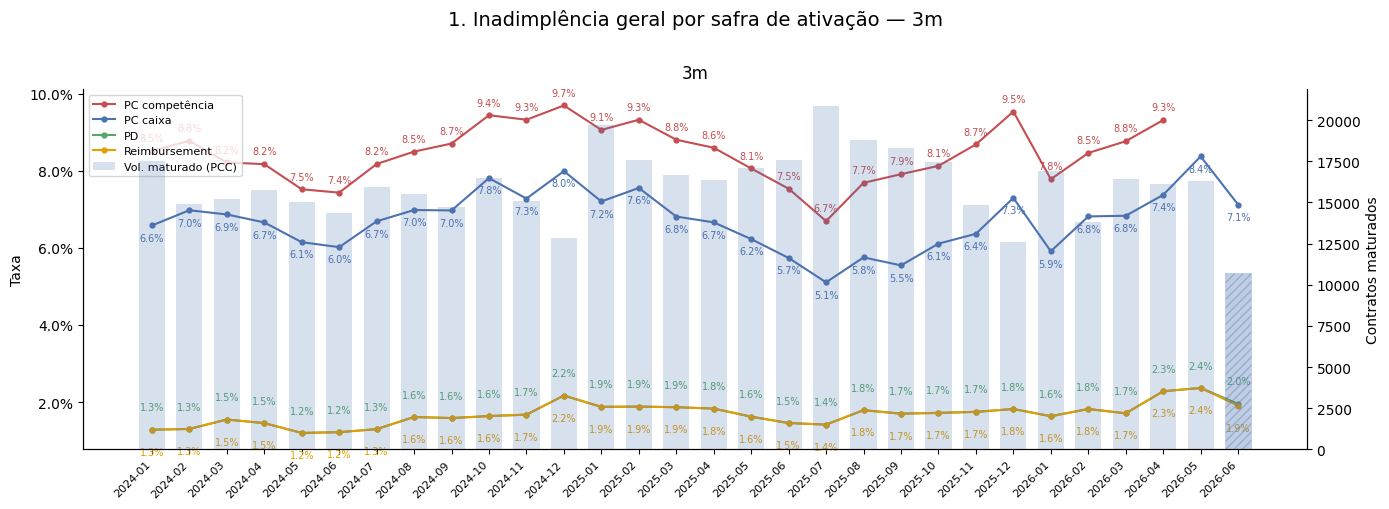

Público maturado (safras incompletas) — 3m


safra,n_ativados,n_maturados,pct_maturado
2026-06,"15,786","10,701",67.8%


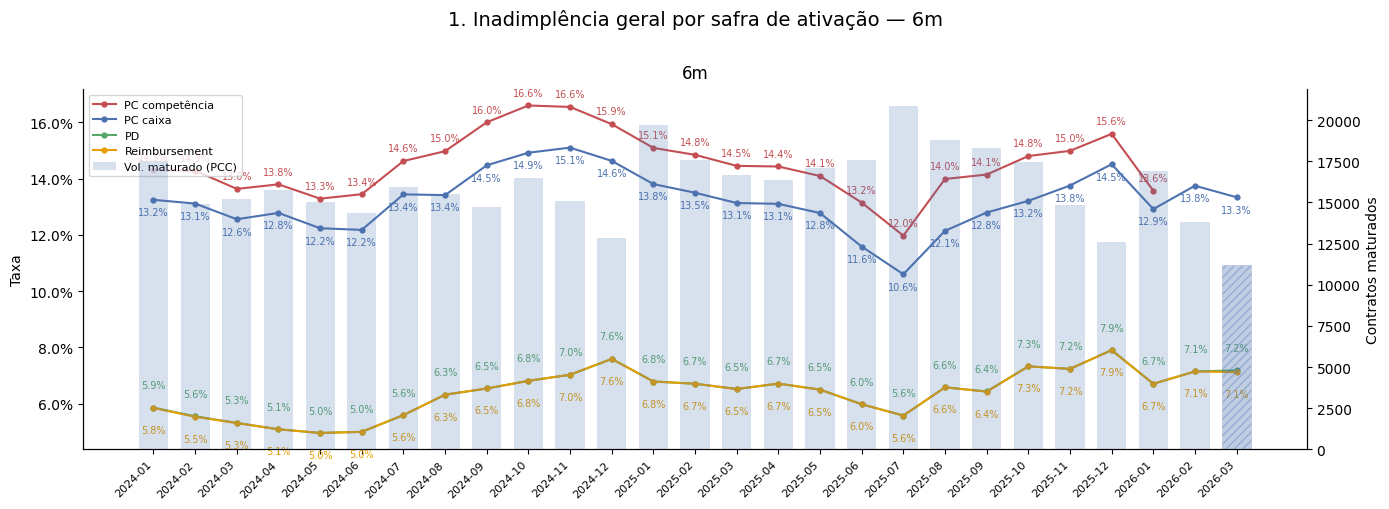

Público maturado (safras incompletas) — 6m


safra,n_ativados,n_maturados,pct_maturado
2026-03,"16,395","11,177",68.2%


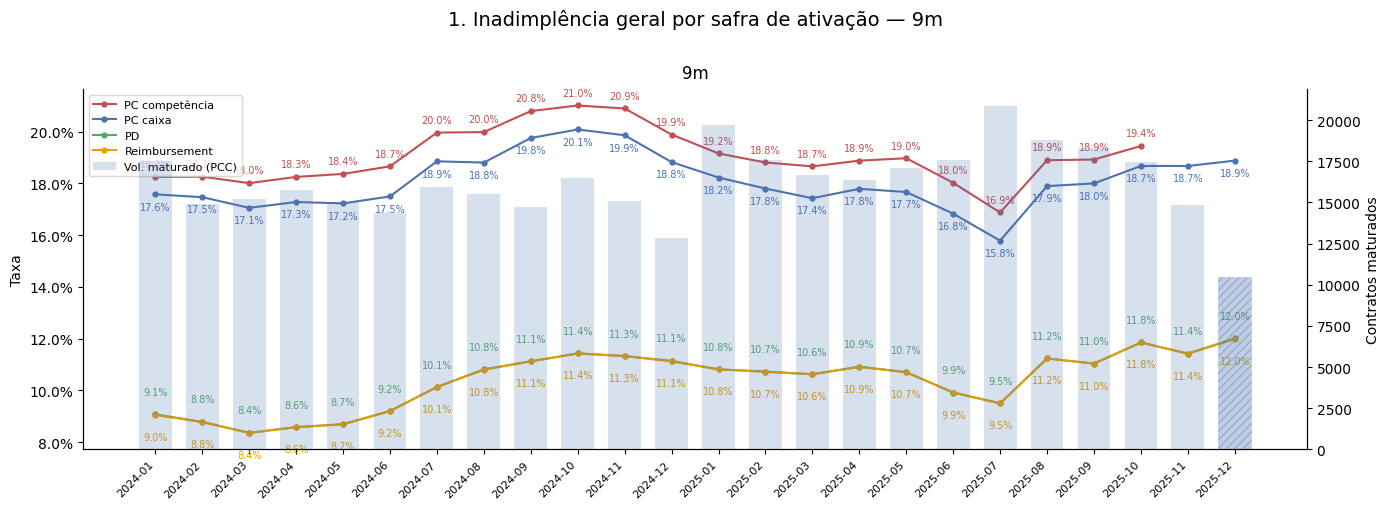

Público maturado (safras incompletas) — 9m


safra,n_ativados,n_maturados,pct_maturado
2025-12,"12,587","10,482",83.3%


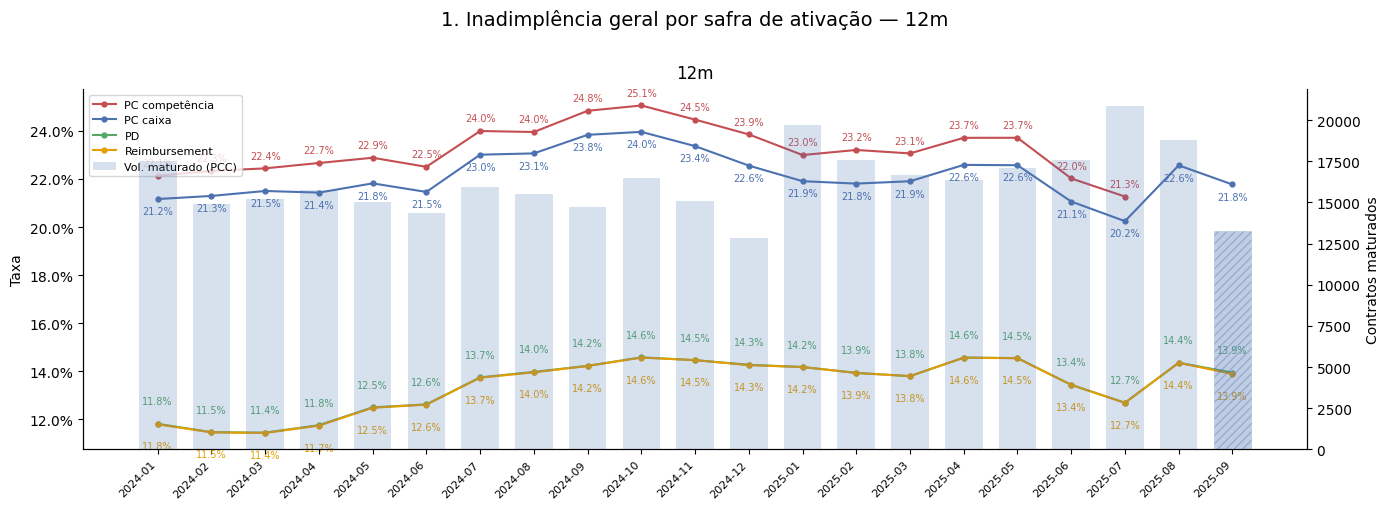

Público maturado (safras incompletas) — 12m


safra,n_ativados,n_maturados,pct_maturado
2025-09,"18,306","13,258",72.4%


In [41]:
show_rate_summary(df_ctr)
plot_default_grid(df_ctr, "1. Inadimplência geral por safra de ativação", windows=[3, 6])
plot_default_grid(df_ctr, "1. Inadimplência geral por safra de ativação", windows=[9, 12])

## 1. Caso geral — Uniproponente

Mesmo recorte do caso geral, só **uniproponente**. Sem quebra por modelo.

,janela,n_ativados,n_maturados_pcc,pct_maturado,pc,pcc,pd,reimbursement
0,3m,"498,833","459,370",92.1%,8.60%,6.84%,1.73%,1.73%
1,6m,"498,833","412,542",82.7%,14.77%,13.44%,6.56%,6.56%
2,9m,"498,833","370,098",74.2%,19.37%,18.38%,10.65%,10.64%
3,12m,"498,833","324,152",65.0%,23.63%,22.51%,13.78%,13.77%


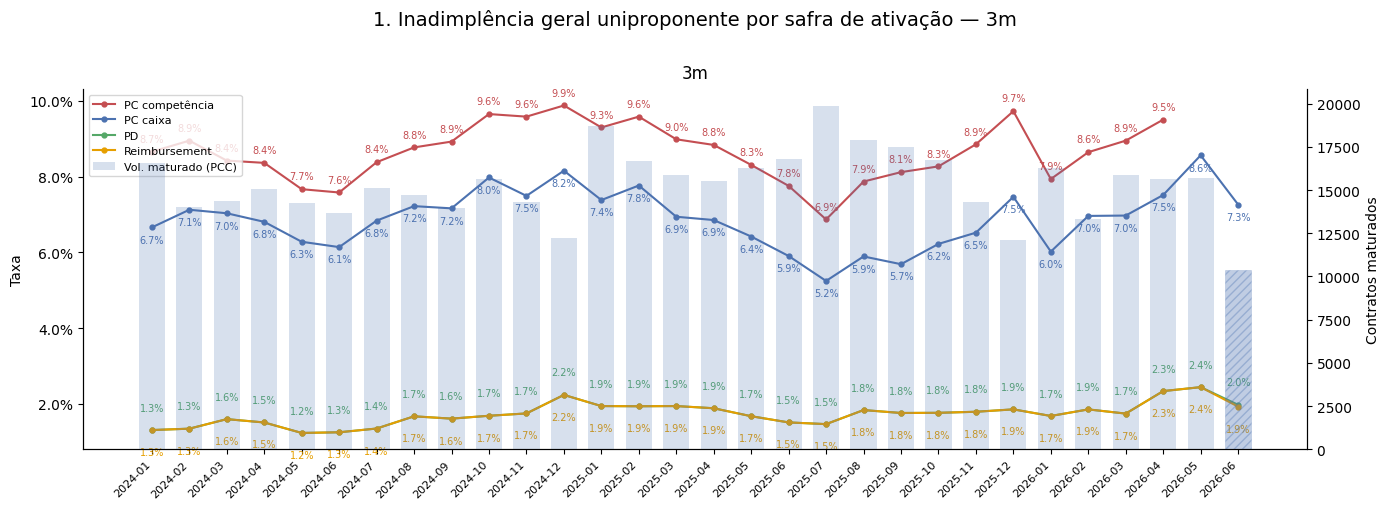

Público maturado (safras incompletas) — 3m


safra,n_ativados,n_maturados,pct_maturado
2026-06,"15,305","10,370",67.8%


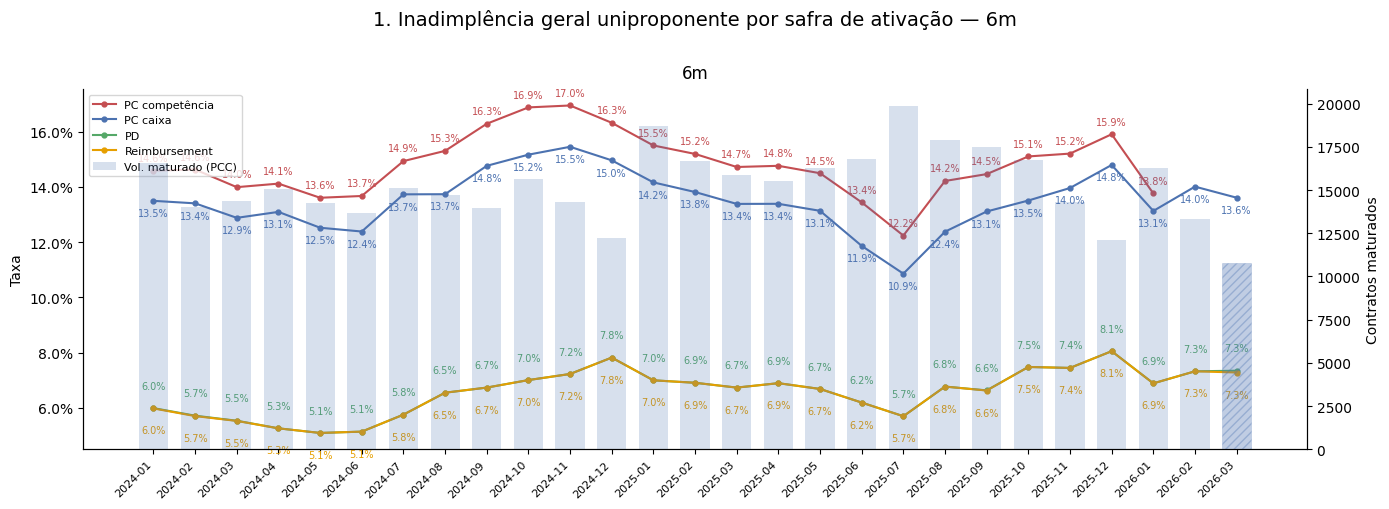

Público maturado (safras incompletas) — 6m


safra,n_ativados,n_maturados,pct_maturado
2026-03,"15,881","10,800",68.0%


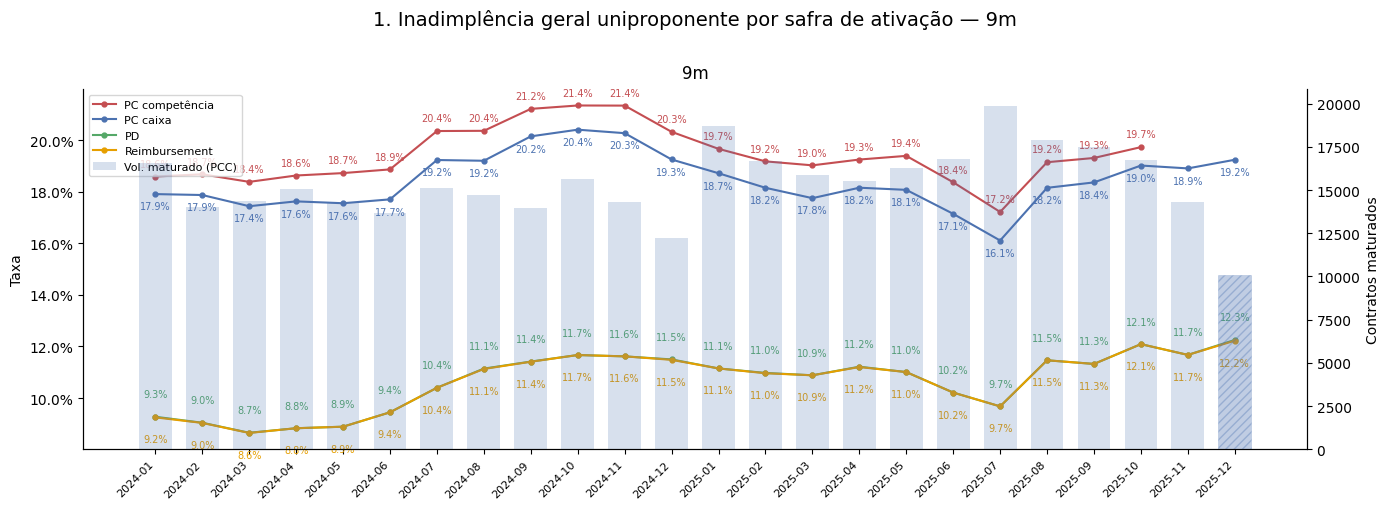

Público maturado (safras incompletas) — 9m


safra,n_ativados,n_maturados,pct_maturado
2025-12,"12,124","10,094",83.3%


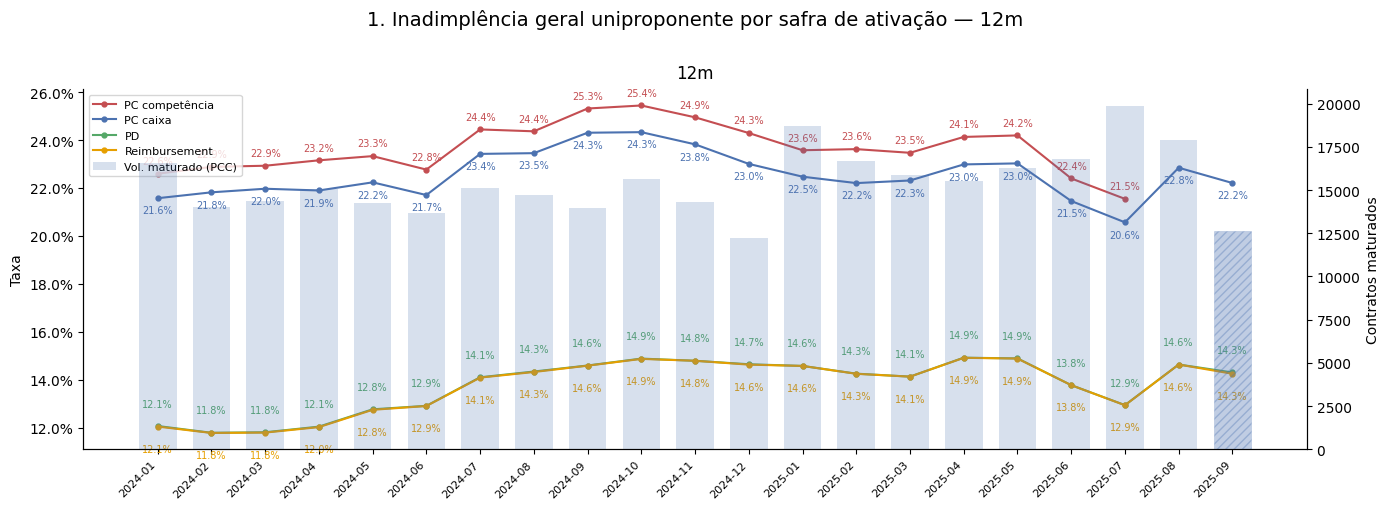

Público maturado (safras incompletas) — 12m


safra,n_ativados,n_maturados,pct_maturado
2025-09,"17,496","12,640",72.2%


In [42]:
df_uni_geral = df_ctr[df_ctr["is_single_proponent"] == 1].copy()
show_rate_summary(df_uni_geral)
plot_default_grid(df_uni_geral, "1. Inadimplência geral uniproponente por safra de ativação", windows=[3, 6])
plot_default_grid(df_uni_geral, "1. Inadimplência geral uniproponente por safra de ativação", windows=[9, 12])

## 2. Por modelo — Uniproponente

Mesmo público uniproponente, quebrado em **BLEND2** / **BLEND3** / **BLEND4**.

Séries a partir de **2026-01** (**BLEND2**), **2026-04** (**BLEND3**) e **2026-07** (**BLEND4**).

,janela,n_ativados,n_maturados_pcc,pct_maturado,pc,pcc,pd,reimbursement
0,3m,"123,130","83,667",68.0%,8.75%,7.28%,2.05%,2.04%
1,6m,"123,130","39,712",32.3%,13.77%,13.55%,7.15%,7.13%


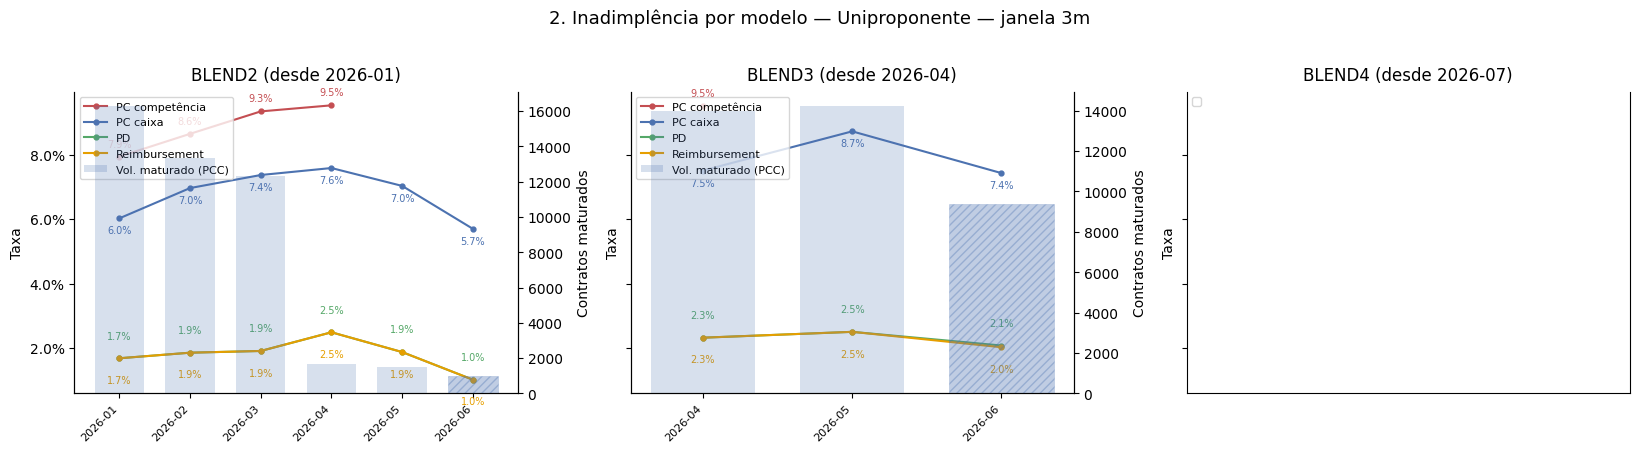

Público maturado (safras incompletas) — 3m


modelo,safra,n_ativados,n_maturados,pct_maturado
BLEND2,2026-06,"1,476",983,66.6%
BLEND3,2026-06,"13,829","9,387",67.9%


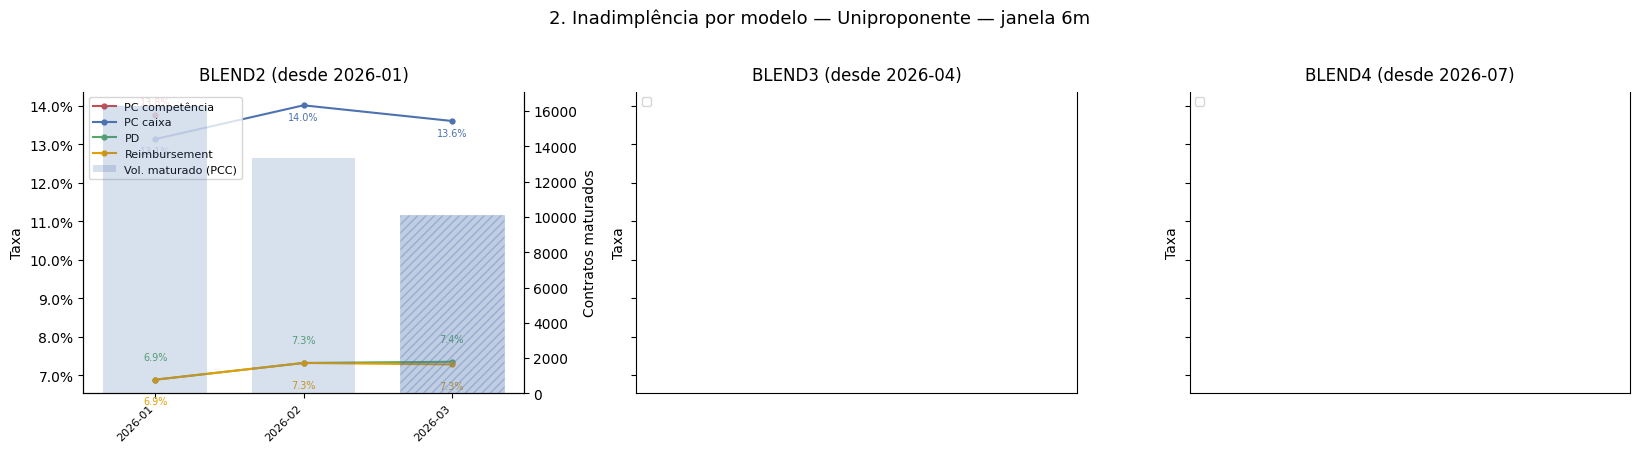

Público maturado (safras incompletas) — 6m


modelo,safra,n_ativados,n_maturados,pct_maturado
BLEND2,2026-03,"12,313","10,105",82.1%


In [43]:
df_model = filter_model_safras(df_ctr[df_ctr["is_single_proponent"] == 1])
show_rate_summary(df_model, windows=WINDOWS_BY_MODEL)
plot_default_by_model(
    df_model,
    "2. Inadimplência por modelo — Uniproponente",
    windows=WINDOWS_BY_MODEL,
)

## 3. Multiproponente

,janela,n_ativados,n_maturados_pcc,pct_maturado,pc,pcc,pd,reimbursement
0,3m,"23,103","21,872",94.7%,4.36%,3.39%,0.58%,0.58%
1,6m,"23,103","20,411",88.3%,8.35%,7.44%,2.77%,2.77%
2,9m,"23,103","18,875",81.7%,11.72%,10.96%,5.12%,5.12%
3,12m,"23,103","17,004",73.6%,14.92%,14.18%,7.07%,7.07%


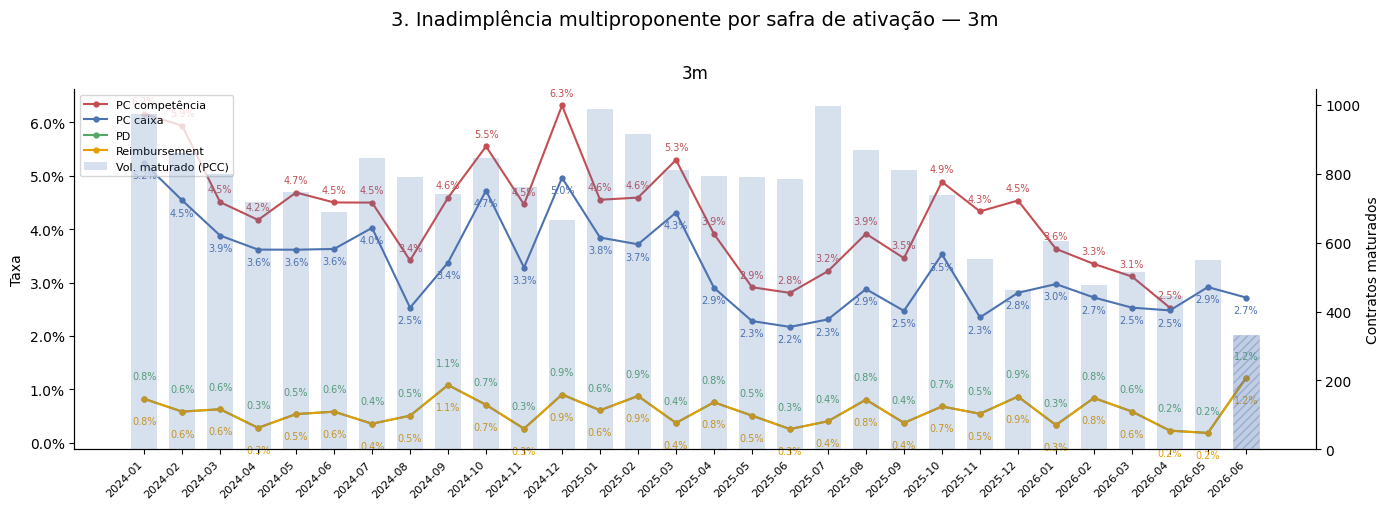

Público maturado (safras incompletas) — 3m


safra,n_ativados,n_maturados,pct_maturado
2026-06,481,331,68.8%


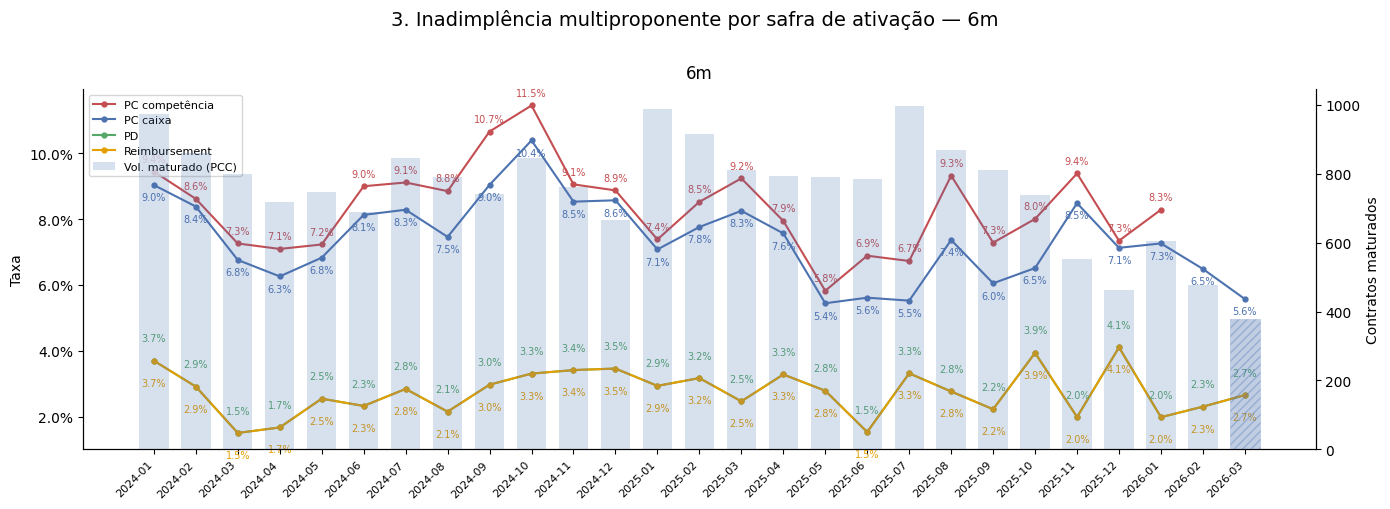

Público maturado (safras incompletas) — 6m


safra,n_ativados,n_maturados,pct_maturado
2026-03,514,377,73.3%


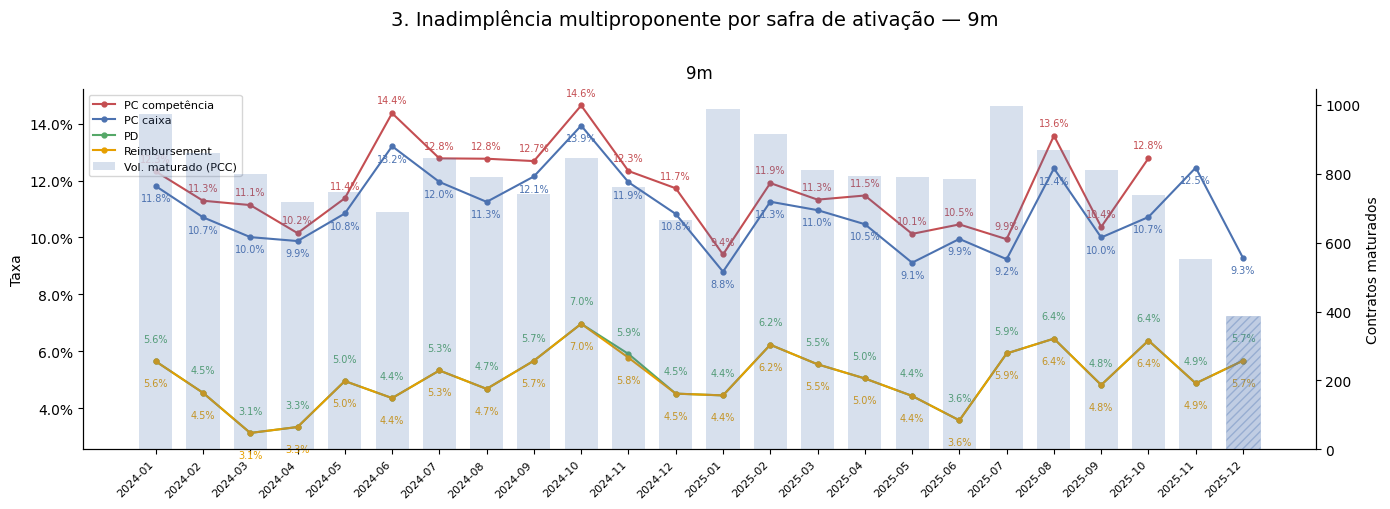

Público maturado (safras incompletas) — 9m


safra,n_ativados,n_maturados,pct_maturado
2025-12,463,388,83.8%


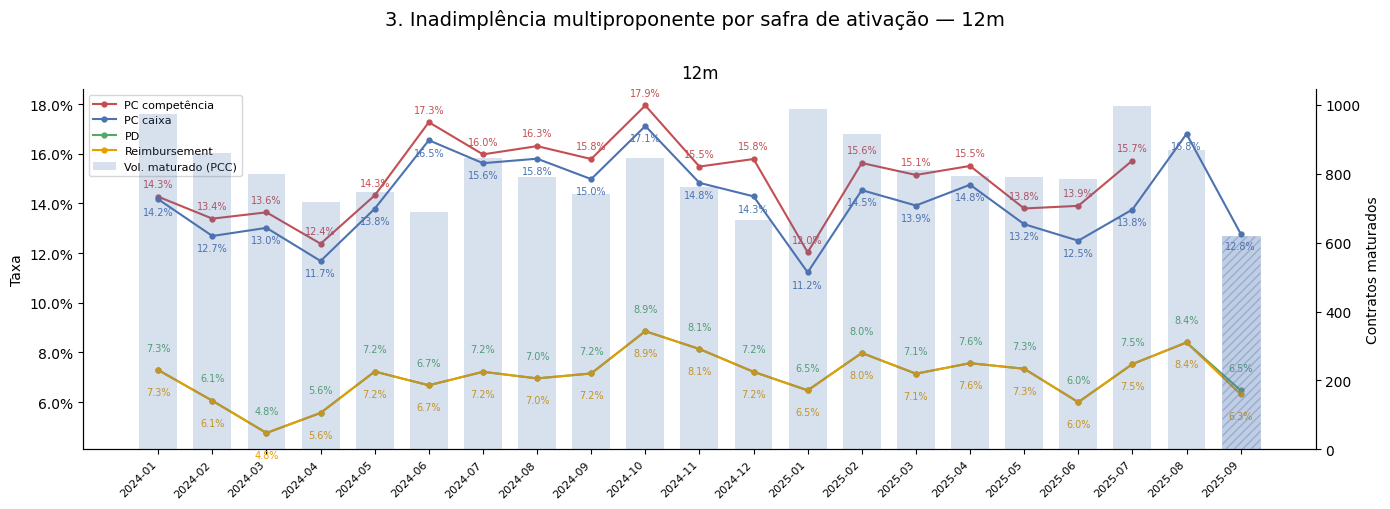

Público maturado (safras incompletas) — 12m


safra,n_ativados,n_maturados,pct_maturado
2025-09,810,618,76.3%


In [44]:
df_multi = df_ctr[df_ctr["is_single_proponent"] == 0].copy()
show_rate_summary(df_multi)
plot_default_grid(df_multi, "3. Inadimplência multiproponente por safra de ativação")

## 4. Mix ao longo da safra

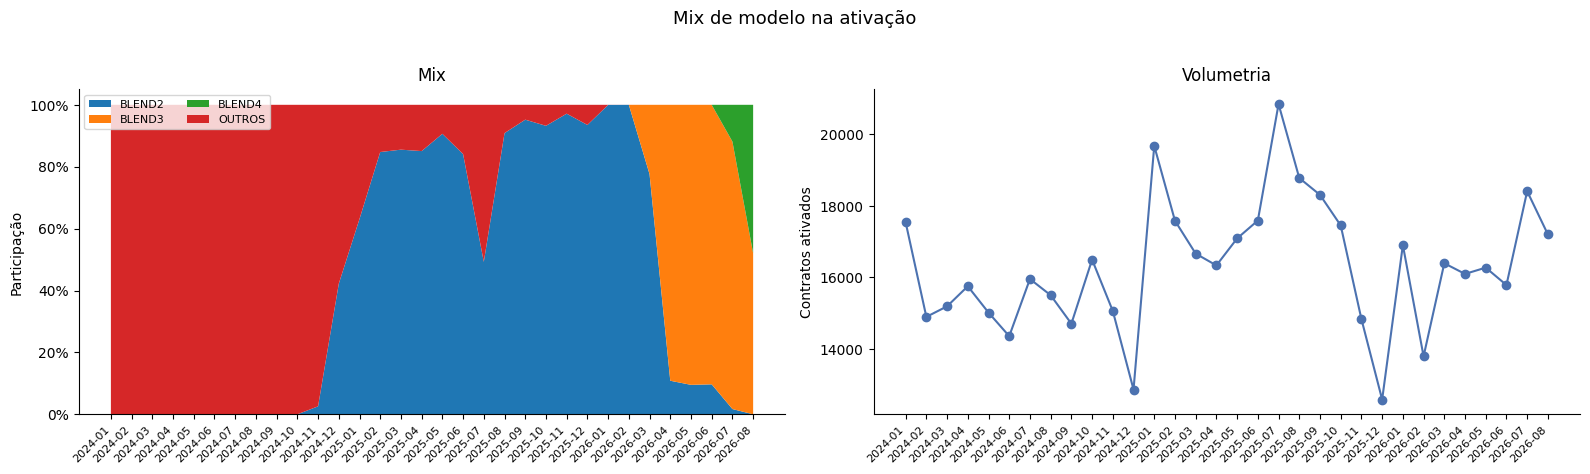

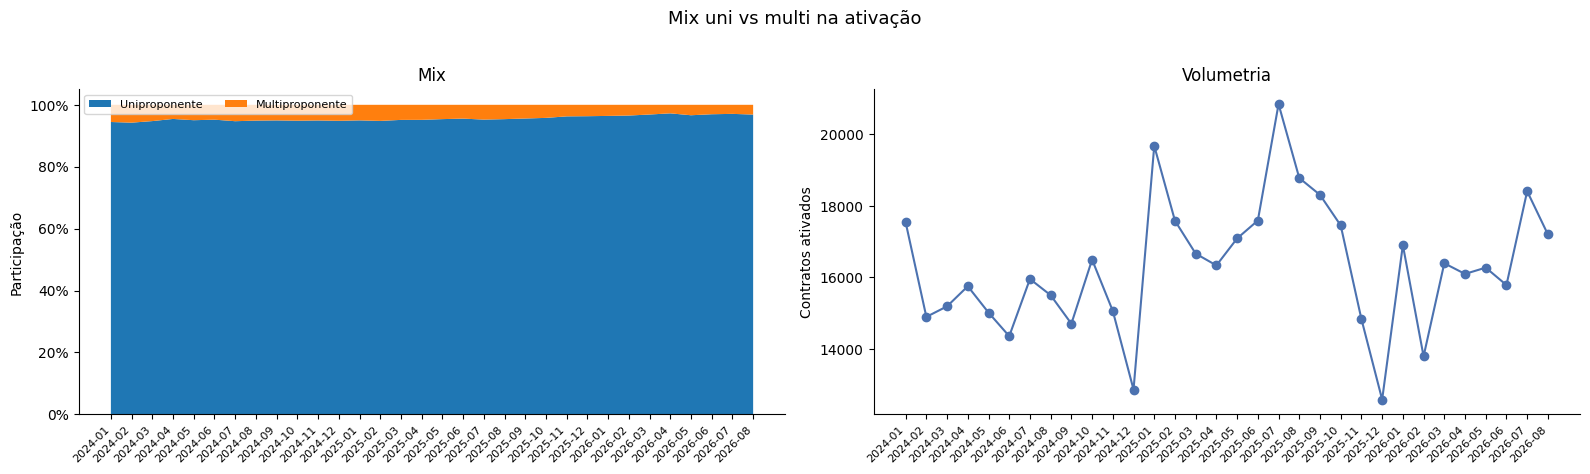

In [45]:
def plot_mix(df: pd.DataFrame, col: str, title: str, order=None) -> None:
    if "n_activated" in df.columns:
        counts = (
            df.pivot_table(
                index="safra_ativacao",
                columns=col,
                values="n_activated",
                aggfunc="sum",
                fill_value=0,
            )
            .sort_index()
        )
    else:
        counts = pd.crosstab(df["safra_ativacao"], df[col], dropna=False)
        print("Mix sem n_activated: cada linha da base agregada conta como 1, não como contrato.")
    if order:
        cols = [c for c in order if c in counts.columns]
        cols += [c for c in counts.columns if c not in cols]
        counts = counts[cols]
    share = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    x = np.arange(len(share))
    fig, axes = plt.subplots(1, 2, figsize=(16, 4.6))

    axes[0].stackplot(x, *[share[c].to_numpy() for c in share.columns], labels=share.columns)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(share.index.astype(str), rotation=45, ha="right", fontsize=8)
    axes[0].set_ylabel("Participação")
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    axes[0].set_title("Mix")
    axes[0].legend(loc="upper left", fontsize=8, ncol=2)
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    axes[1].plot(x, counts.sum(axis=1).to_numpy(), marker="o", color="#4C72B0")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(share.index.astype(str), rotation=45, ha="right", fontsize=8)
    axes[1].set_ylabel("Contratos ativados" if "n_activated" in df.columns else "Células agregadas")
    axes[1].set_title("Volumetria")
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

    fig.suptitle(title, fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()


plot_mix(
    df_ctr.assign(modelo=df_ctr["bureau_nm_ajust"].fillna("Outros")),
    "modelo",
    "Mix de modelo na ativação",
    order=["BLEND2", "BLEND3", "BLEND4", "Outros"],
)
plot_mix(
    df_ctr.assign(
        proponente=np.where(df_ctr["is_single_proponent"] == 1, "Uniproponente", "Multiproponente")
    ),
    "proponente",
    "Mix uni vs multi na ativação",
    order=["Uniproponente", "Multiproponente"],
)

## Salvar HTML

In [46]:
import importlib

import build_report_html

importlib.reload(build_report_html)

REPORTS_DIR = Path("Monitores")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

report_path = build_report_html.export_notebook_report(
    title="Monitoramento Performance de Modelos",
    output_path=REPORTS_DIR / "02.Monitoramento_Performance_de_Modelos_report.html",
)
print(f"Report generated: {report_path}")


Report updated: /Users/lucas.nascimento/Monitoramento_Modelos/Monitores/02.Monitoramento_Performance_de_Modelos_report.html (2.50 MB) | generated at 2026-09-17 17:26:01 -03
If the browser still shows old content, hard-refresh (Cmd+Shift+R).
Report generated: /Users/lucas.nascimento/Monitoramento_Modelos/Monitores/02.Monitoramento_Performance_de_Modelos_report.html
